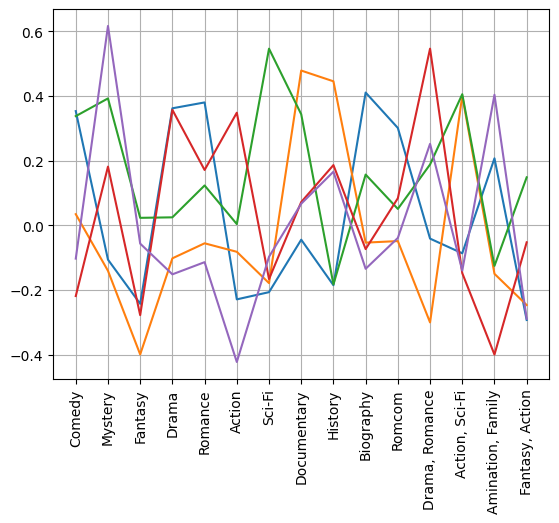

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("../data_sets/recom.csv")
# print(df.head())
x = df.to_numpy()

P = len(x[0,1:])  # First row, all columns but the first since that is genres
x_train = x[:, 1:P].T
x_new = x[:, P].reshape(1, -1)

# Standard normalization
scalar = StandardScaler()
scalar.fit(x_train)
u_train = scalar.transform(x_train)

# Applying PCA
C = PCA(5)
C.fit(u_train)

# Let us see the principal components
plt.plot(C.components_[:,:].T)
plt.xticks([i for i in range(15)], x[:, 0], rotation = 90)
plt.grid()
plt.show()

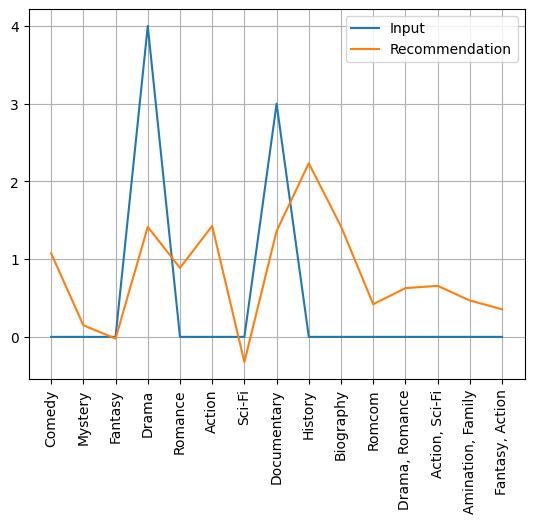

In [7]:
# Transform the new user
u_new = scalar.transform(x_new)
w_new_pca = C.transform(u_new)

ut_new = np.matmul(w_new_pca, C.components_)
xt_new = scalar.inverse_transform(ut_new)

plt.plot(x_new[0, :], label = "Input")
plt.plot(xt_new[0, :], label = "Recommendation")
plt.xticks([i for i in range(15)], x[:, 0], rotation = 90)
plt.grid()
plt.legend()
plt.show()